In [1]:
%load_ext autoreload
%autoreload 2

In [34]:
from ariel_pred.dataset import DataLoaderAndCalibrator
from ariel_pred.preprocessing import SGSmoothing
from ariel_pred.plots import plot_white_curve
from ariel_pred.transit import FunctionFittingBasedPhaseDetector
from ariel_pred.models import TransitMultiplicationFactorFinder, SValuesCNN, SValuesCNNTrainer
from ariel_pred.features import WavelengthsGroupsMultiplierFinder
from ariel_pred.metrics import score, gll
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random
from scipy.optimize import minimize
from tqdm.auto import tqdm
import pandas as pd
import torch
from torch import nn
import scipy

In [3]:
data_loader = DataLoaderAndCalibrator(
    data_path=Path("../data/raw"),
    output_path=Path("../data/calibrated/full"),
    force_recalibration=False,
    cut_airs_channels=True,
    binning=4,
    n_jobs=4
)
train_data, train_labels = data_loader.load_all_train_data()
train_data.shape, train_labels.shape

Loading calibrated train data...


((1100, 1406, 283), (1100, 283))

In [4]:
features_extractor = WavelengthsGroupsMultiplierFinder()

features = features_extractor.extract_features(
    train_data,
    average_cross_groups=False,
    wavelengths_groups=[1, 2, 4, 8, 16, 32, 64, 283 // 2, 283],
    weights=[1, 1, 1, 1, 1, 1, 1, 1, 1]
)

features.shape

100%|██████████| 1100/1100 [13:39<00:00,  1.34it/s]


(1100, 283, 9)

In [5]:
cnn_train_data = features.transpose(0, 2,1)
cnn_train_data.shape

(1100, 9, 283)

In [6]:
trainer = SValuesCNNTrainer(
    Path("../models/s_values_cnn"),
    device=torch.device("mps"),
    in_channels=cnn_train_data.shape[1],
    num_channels=283
)

In [9]:
trainer = SValuesCNNTrainer(
    Path("../models/s_values_cnn"),
    device=torch.device("mps"),
    in_channels=cnn_train_data.shape[1],
    num_channels=283,
    train_multiplier=1e3
)

res = trainer.train(cnn_train_data, train_labels, n_splits=5, return_predictions=True)

if res is not None:
    spectrum, sigma, (val_rmse, val_gll, val_loss, train_loss) = res # type: ignore

No saved models found in the specified path. Starting training from scratch.


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

In [184]:
np.mean((spectrum - train_labels)**2)**0.5, np.mean((0.945*features.mean(axis=2) - train_labels)**2)**0.5

(np.float64(0.0007128153603641256), np.float64(0.0007461948027420565))

In [17]:
f"{(0.0007237995244922738 / 0.0007128153603641256 - 1.0 ) * 100:.3f}%"

'1.541%'

In [ ]:
def cost_function(params, x, mu):
    sigma = params[0]
    return 0.5 * (np.log(2 * np.pi) + np.log(sigma**2) + ((x - mu)**2) / (sigma**2))

In [20]:
optimal_sigma = np.zeros_like(spectrum)

for i in tqdm(range(spectrum.shape[0])):
    for j in range(spectrum.shape[1]):
        res = minimize(cost_function, [0.00068], args=(train_labels[i, j], spectrum[i, j]))
        optimal_sigma[i, j] = res.x[0]

  0%|          | 0/1100 [00:00<?, ?it/s]

In [22]:
optimal_sigma.mean()

np.float64(0.00028695933941193637)

In [59]:
gll(np.concatenate([spectrum, optimal_sigma], axis=1), train_labels)

GLL_pred shape: (1100, 283)
GLL_ref shape: (1100, 283)
GLL_ideal shape: (1100, 283)
0 0 0
-8.152484406692726e+25 6.021898596172263 6.813249706319847 7.5910865902929086 13.865437910381491
-7.71785535915249e+21


0.0

In [61]:
(optimal_sigma < 1e-15).sum()

np.int64(27176)

In [60]:
optimal_sigma.clip(min=1e-15)

array([[1.73107767e-04, 1.73315857e-04, 1.50999014e-04, ...,
        1.15469788e-04, 7.31466484e-05, 3.32780743e-04],
       [7.43756369e-04, 4.88566308e-04, 4.72229207e-04, ...,
        1.88619732e-04, 3.41223740e-04, 2.62606057e-04],
       [1.00000000e-15, 1.65128634e-03, 1.60311696e-03, ...,
        1.49073644e-03, 1.60700878e-03, 1.69468184e-03],
       ...,
       [1.01423378e-04, 1.44679921e-04, 1.39597232e-04, ...,
        7.09539142e-05, 9.73782228e-05, 8.86277622e-05],
       [2.64167468e-04, 6.93547164e-05, 5.48301309e-05, ...,
        1.75031362e-04, 1.36071321e-04, 7.35566103e-05],
       [1.02879450e-03, 7.95820503e-04, 7.96070238e-04, ...,
        1.00000000e-15, 5.68074695e-04, 5.92883787e-04]],
      shape=(1100, 283))

In [32]:
-0.5 * (((spectrum - train_labels)**2 / optimal_sigma**2) + np.log(2 * np.pi * optimal_sigma**2))

array([[7.24261532, 7.24141396, 7.37925024, ..., 7.64749863, 8.10402926,
        6.58906579],
       [5.7848557 , 6.20509441, 6.23909203, ..., 7.15682625, 6.5640319 ,
        6.82588863],
       [4.58469896, 4.98725765, 5.01686386, ..., 5.08954603, 5.01443927,
        4.96131733],
       ...,
       [7.77719581, 7.42199804, 7.45781163, ..., 8.1344388 , 7.81789331,
        7.91212245],
       [6.81996057, 8.15729272, 8.39219634, ..., 7.23156461, 7.48334402,
        8.09845155],
       [5.46042858, 5.71718909, 5.71687566, ..., 6.10478055, 6.05430715,
        6.01156397]], shape=(1100, 283))

In [168]:
sigma.min()

np.float64(0.00014072106569074094)

In [170]:
gll(np.concatenate([spectrum, sigma], axis=1), train_labels)

0.3684159968698605

In [110]:
y_ref = 0.014689019532534079 * np.ones_like(spectrum)
y_ideal = train_labels
sigma_ref = 0.010661335331978338 * np.ones_like(optimal_sigma)
sigma_ideal = 1e-5 * np.ones_like(optimal_sigma)
sigma_ideal[:, 0] = 1e-6
GLL_Pred = scipy.stats.norm.logpdf(train_labels, loc=spectrum, scale=optimal_sigma.clip(min=1e-5))
GLL_ref = scipy.stats.norm.logpdf(train_labels, loc=y_ref, scale=sigma_ref)
GLL_ideal = scipy.stats.norm.logpdf(train_labels, loc=y_ideal, scale=sigma_ideal)

In [111]:
# Find nans
np.isnan(GLL_Pred).sum(), np.isnan(GLL_ref).sum(), np.isnan(GLL_ideal).sum(), np.isnan(spectrum).sum(), np.isnan(optimal_sigma).sum()

(np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0))

In [112]:
ind_scores = (GLL_Pred - GLL_ref) / (GLL_ideal - GLL_ref)

In [113]:
np.median(ind_scores)

np.float64(0.48508256623870416)

In [114]:
ind_scores.mean()

np.float64(-69.67923779298366)

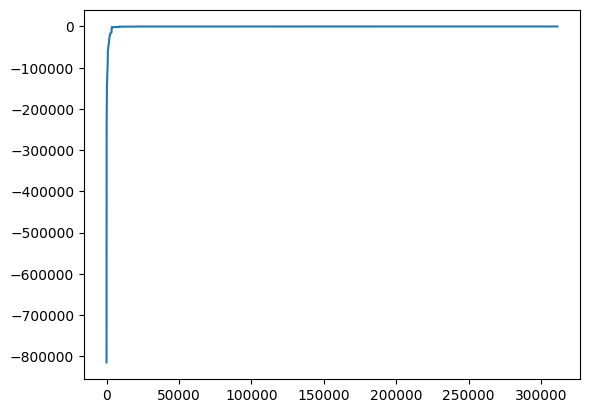

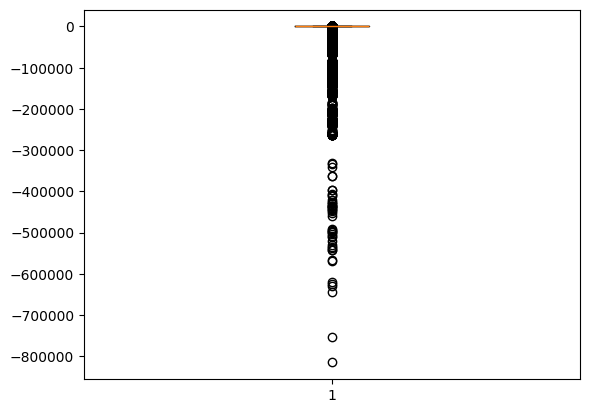

In [118]:
plt.plot(np.sort(GLL_Pred.flatten()))
plt.show()
plt.boxplot(np.sort(GLL_Pred.flatten()))
plt.show()

In [166]:
optimal_sigma.min()

np.float64(-0.012769098592155524)

In [165]:
df = pd.DataFrame({
    "spectrum": spectrum.flatten(),
    "train_labels": train_labels.flatten(),
    "optimal_sigma": optimal_sigma.flatten(),
    "div": ((spectrum - train_labels)**2 / optimal_sigma**2).flatten(),
    "add": np.log(2*np.pi*optimal_sigma**2).flatten(),
    "test": -0.5 * (((spectrum - train_labels)**2 / optimal_sigma**2).flatten() + np.log(2*np.pi*optimal_sigma**2).flatten()).flatten(),
    "tes2": -0.5 * (((spectrum - train_labels)**2 / optimal_sigma.clip(min=1e-10)**2) + np.log(2 * np.pi * optimal_sigma.clip(min=1e-10)**2)).flatten(),
    "ex_gll": -0.5 * (((spectrum - train_labels)**2 / optimal_sigma**2) + np.log(2 * np.pi * optimal_sigma**2)).flatten(),
    "GLL_Pred": GLL_Pred.flatten(),
    "ind_scores": ind_scores.flatten(),
    "GLL_ref": GLL_ref.flatten(),
    "GLL_ideal": GLL_ideal.flatten(),
})
df['ex_gll'] = -0.5*(df['div'] + df['add'])
df.sort_values('ind_scores')

,spectrum,train_labels,optimal_sigma,div,add,test,tes2,ex_gll,GLL_Pred,ind_scores,GLL_ref,GLL_ideal
274054,0.041022,0.031116,-9.905449e-03,1.000000,-7.391463,3.195732,-4.905895e+15,3.195732,-490578.871227,-60128.849559,2.435153,10.593987
273946,0.037137,0.027549,-9.587417e-03,1.000000,-7.456730,3.228365,-4.595926e+15,3.228365,-459582.018221,-59691.776196,2.894687,10.593987
274052,0.039758,0.030382,-9.376262e-03,0.999998,-7.501271,3.250636,-4.395708e+15,3.250636,-439560.190449,-54569.835096,2.538937,10.593987
101058,0.073656,0.060886,-1.276910e-02,0.999999,-6.883577,2.941789,-8.152484e+15,2.941789,-815237.846682,-49830.854747,-5.765999,10.593987
101057,0.073646,0.061362,-1.228425e-02,1.000000,-6.960997,2.980499,-7.545140e+15,2.980499,-754503.438033,-45577.545169,-5.960162,10.593987
...,...,...,...,...,...,...,...,...,...,...,...,...
33088,0.007321,0.007322,3.903805e-07,1.037831,-27.674411,13.318290,1.331829e+01,13.318290,10.593196,0.999890,3.383435,10.593987
274771,0.007846,0.007847,3.877279e-07,1.038113,-27.688047,13.324967,1.332497e+01,13.324967,10.593207,0.999891,3.416250,10.593987
151428,0.013190,0.013190,2.236269e-07,1.065698,-28.788696,13.861499,1.386150e+01,13.861499,10.593720,0.999962,3.612306,10.593987
123586,0.007000,0.007000,2.236568e-07,1.065684,-28.788429,13.861373,1.386137e+01,13.861373,10.593720,0.999963,3.362128,10.593987


In [142]:
a = scipy.stats.norm.logpdf(train_labels, loc=spectrum, scale=optimal_sigma.clip(min=1e-10))

In [143]:
b = -0.5 * (((spectrum - train_labels)**2 / optimal_sigma.clip(min=1e-10)**2) + np.log(2 * np.pi * optimal_sigma.clip(min=1e-10)**2))

In [153]:
c = np.log(2 * np.pi * optimal_sigma.clip(min=1e-10)**2)

In [154]:
d = np.log(2 * np.pi) + np.log(optimal_sigma.clip(min=1e-10)**2)

In [125]:
(ind_scores < 0).sum() / ind_scores.size

np.float64(0.07624799229039511)

In [ ]:
np.log(2 * np.pi)

np.float64(1.8378770664093453)

In [49]:
weights = np.append(np.array([57.846]), np.ones(train_labels.shape[1] - 1))
weights = weights * np.ones_like(ind_scores)
submit_score = np.average(ind_scores, weights=weights)

In [ ]:
submit_score

In [50]:
float(np.average(submit_score).clip(0, 1))

nan

In [172]:
np.sqrt(0.1/(2*np.pi))

np.float64(0.126156626101008)

In [183]:
np.log(2*np.pi*((1e-6)**2))

np.float64(-25.793144049519203)